 ### Configure and Run a Large-Scale MRB Simulation

This section sets up a **30-qubit noisy quantum simulator** for large-scale Mirror Randomized Benchmarking. It initializes the random seed for reproducible results, defines the device connectivity (coupling map), creates a depolarizing noise model, and configures an `AerSimulator` backend. The **number of qubits, noise probabilities (`p1`, `p2`), circuit lengths, shots, number of samples, and random seed are all configurable parameters** that can be adjusted to simulate different devices or benchmarking conditions. Finally, the MRB experiment is executed, and the generated job ID is displayed for reference.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import CouplingMap
from qiskit.transpiler import Target
from qiskit_device_benchmarking.bench_code.mrb import MirrorRB
import os, random

# Fix random seed for numpy
SEED = 123 # pick your favorite int
os.environ["PYTHONHASHSEED"] = str(SEED)  # optional, for hash-based determinism
random.seed(SEED)
np.random.seed(SEED)

# Set up parameters for a large-scale benchmarking experiment
num_qubits = 30
basis_gates = ["id", "h", "x", "y", "z", "s", "cx"]
p1 = 0.001  # 1-qubit gate error probability
p2 = 0.01   # 2-qubit gate error probability



fez_edges_30 = [
 (0, 1), (1, 0), (1, 2), (2, 1), (2, 3), (3, 2), (3, 4), (3, 16), (4, 3), (4, 5), (5, 4), (5, 6), (6, 5), (6, 7), 
 (7, 6), (7, 8),(7, 17), (8, 7), (8, 9), (9, 8), (9, 10), (10, 9), (10, 11), (11, 10), (11, 12), (11, 18), (12, 11), 
 (12, 13), (13, 12), (13, 14), (14, 13), (14, 15),(15, 14), (15, 19), (16, 3), (16, 23), (17, 7), (17, 27), (18, 11), 
 (19, 15),(20, 21), (21, 20), (21, 22), (22, 21), (22, 23), (23, 16), (23, 22), (23, 24), (24, 23), (24, 25), (25, 24), 
 (25, 26), (26, 25), (26, 27), (27, 17), (27, 26), (27, 28), (28, 27), (28, 29), (29, 28), (29, 30), (30, 29)
]



coupling_map = CouplingMap(fez_edges_30)

# Target for the backend
target = Target.from_configuration(
    num_qubits=num_qubits,
    basis_gates=basis_gates,
    coupling_map=coupling_map,
    # No custom_name_mapping needed for AerSimulator's stabilizer method
)

# Noise model with depolarizing errors
noise_model = NoiseModel()
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)
for gate in basis_gates:
    if gate in ["id", "h", "x", "y", "z", "s"]:
        noise_model.add_all_qubit_quantum_error(error_1q, gate)
    elif gate == "cx":
        noise_model.add_all_qubit_quantum_error(error_2q, gate)


# Setup AerSimulator for Clifford circuits
backend = AerSimulator(
    method="stabilizer",
    noise_model=noise_model,
    target=target,
    max_parallel_threads=0,
    max_parallel_experiments=0,
    seed_simulator=SEED
)


# Use all system threads for experiments

# Parameters for benchmarking run
shots = 10000  # Reduce shots for debugging, raise for production runs
lengths = [2, 4, 10, 20, 50]  # Adjust as needed
num_samples = 20 # Adjust for speed vs. statistics

# Set up and run MirrorRB experiment
exp = MirrorRB(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=num_samples,
    seed=SEED
)
exp.set_run_options(shots=shots)
rb_data = exp.run()
print("Job IDs:", rb_data.job_ids if hasattr(rb_data, "job_ids") else "N/A")


Job IDs: ['02679986-531e-40e8-9b87-7c78e62ace29']


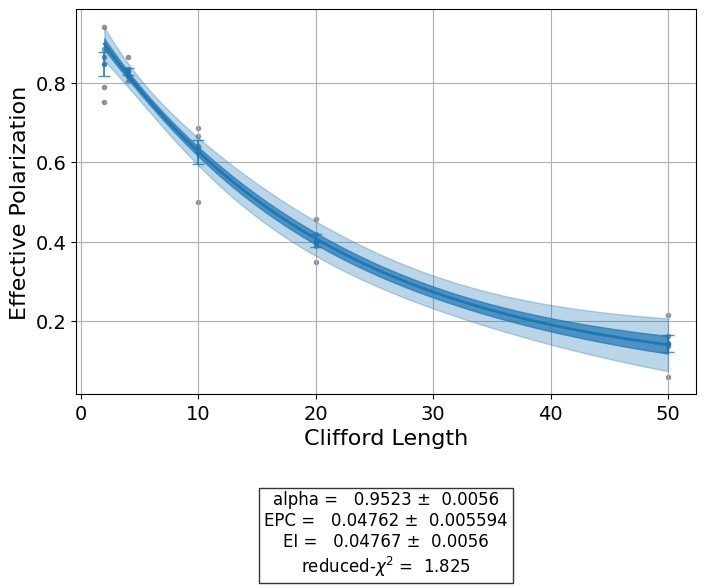

In [2]:
from qiskit_device_benchmarking.bench_code.mrb.mirror_rb_analysis import MirrorRBAnalysis

analysis_obj = MirrorRBAnalysis()
analysis_obj.set_options(analyzed_quantity='Effective Polarization')
analysis = analysis_obj.run(rb_data)
analysis.block_for_results()
analysis.figure(0)